<a href="https://colab.research.google.com/github/abduvokhid25/compyuter_vision/blob/main/pytorch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch

In [2]:
print(torch.__version__)

2.11.0+cpu


In [3]:
print("CUDA available:", torch.cuda.is_available)

CUDA available: <function is_available at 0x7ff64c812b60>


In [4]:
scalar = torch.tensor(5) # 0D
print('scalar:', scalar)
print('Shape:', scalar.shape)
print('Number of dimensions:', scalar.ndim)
print('Size:', scalar.size())


scalar: tensor(5)
Shape: torch.Size([])
Number of dimensions: 0
Size: torch.Size([])


In [5]:
vector = torch.tensor([1, 2, 3]) # 1D
print('vector:', vector)
print('Shape:', vector.shape)
print('Number of dimensions:', vector.ndim)
print('Size:', vector.size())

vector: tensor([1, 2, 3])
Shape: torch.Size([3])
Number of dimensions: 1
Size: torch.Size([3])


In [6]:
MATRIX = torch.tensor([[1, 2, 3], [4, 5, 6]]) # 2D
print('MATRIX:', MATRIX)
print('Shape:', MATRIX.shape)
print('Number of dimensions:', MATRIX.ndim)
print('Size:', MATRIX.size())

MATRIX: tensor([[1, 2, 3],
        [4, 5, 6]])
Shape: torch.Size([2, 3])
Number of dimensions: 2
Size: torch.Size([2, 3])


In [7]:
tensor3d = torch.stack([MATRIX, MATRIX + 10]) # 3D
print('tensor3d:', tensor3d)
print('Shape:', tensor3d.shape) # [2, 2, 3] 2matrices => channels | 2 rows in each matrix
print('Number of dimensions:', tensor3d.ndim)
print('Size:', tensor3d.size())

tensor3d: tensor([[[ 1,  2,  3],
         [ 4,  5,  6]],

        [[11, 12, 13],
         [14, 15, 16]]])
Shape: torch.Size([2, 2, 3])
Number of dimensions: 3
Size: torch.Size([2, 2, 3])


In [8]:
import torch
random_numbers = torch.rand(2, 3) # 0 ~ 1
print('random numbers:', random_numbers)
print('Data type:', random_numbers.dtype)
print('Device ofrandom numbers:', random_numbers.device)

random numbers: tensor([[0.8745, 0.0134, 0.9136],
        [0.3127, 0.1954, 0.4169]])
Data type: torch.float32
Device ofrandom numbers: cpu


In [9]:
print('zeros:', torch.zeros(3, 3))

zeros: tensor([[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]])


In [10]:
print('ones:', torch.ones(2, 4))

ones: tensor([[1., 1., 1., 1.],
        [1., 1., 1., 1.]])


In [11]:
x = torch.tensor([[1, 2],
                  [3, 4]])
y = torch.tensor([[5, 6],
                  [7, 8]])

# element-wise addition
print('addition:', x + y)
print('================')

# element-wise multiplication
print('multiplication:', x * y)

# matrix multiplication
print('matrix multiplication:', x @ y)
# print('matrix multiplication:', torch.matmul(x, y))

addition: tensor([[ 6,  8],
        [10, 12]])
multiplication: tensor([[ 5, 12],
        [21, 32]])
matrix multiplication: tensor([[19, 22],
        [43, 50]])


In [12]:
# Import PyTorch and matplotlib
import torch
from torch import nn  # nn contains all of PyTorch's building blocks for neural networks
import matplotlib.pyplot as plt

# Check PyTorch version
torch.__version__

'2.11.0+cpu'

In [13]:
# Setup device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cpu


In [16]:
# Create weight and bias
weight = 0.7
bias = 0.3

# Create range values
start = 0
end = 1
step = 0.02

# Create X and y (features and labels)
X = torch.arange(start, end, step).unsqueeze(dim=1)
# without unsqueeze, errors will happen later on (shapes within linear layers)

y = weight * X + bias
# Liner regression: y =wx + b
print('X:', X)
print('\n y:', y)

# Split data
train_split = int(0.8 * len(X)) # 100 data => 80train | 20test

X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]
len(X_train), len(y_train), len(X_test),len(y_test)

X: tensor([[0.0000],
        [0.0200],
        [0.0400],
        [0.0600],
        [0.0800],
        [0.1000],
        [0.1200],
        [0.1400],
        [0.1600],
        [0.1800],
        [0.2000],
        [0.2200],
        [0.2400],
        [0.2600],
        [0.2800],
        [0.3000],
        [0.3200],
        [0.3400],
        [0.3600],
        [0.3800],
        [0.4000],
        [0.4200],
        [0.4400],
        [0.4600],
        [0.4800],
        [0.5000],
        [0.5200],
        [0.5400],
        [0.5600],
        [0.5800],
        [0.6000],
        [0.6200],
        [0.6400],
        [0.6600],
        [0.6800],
        [0.7000],
        [0.7200],
        [0.7400],
        [0.7600],
        [0.7800],
        [0.8000],
        [0.8200],
        [0.8400],
        [0.8600],
        [0.8800],
        [0.9000],
        [0.9200],
        [0.9400],
        [0.9600],
        [0.9800]])

 y: tensor([[0.3000],
        [0.3140],
        [0.3280],
        [0.3420],
        [0.3560],
 

(40, 40, 10, 10)

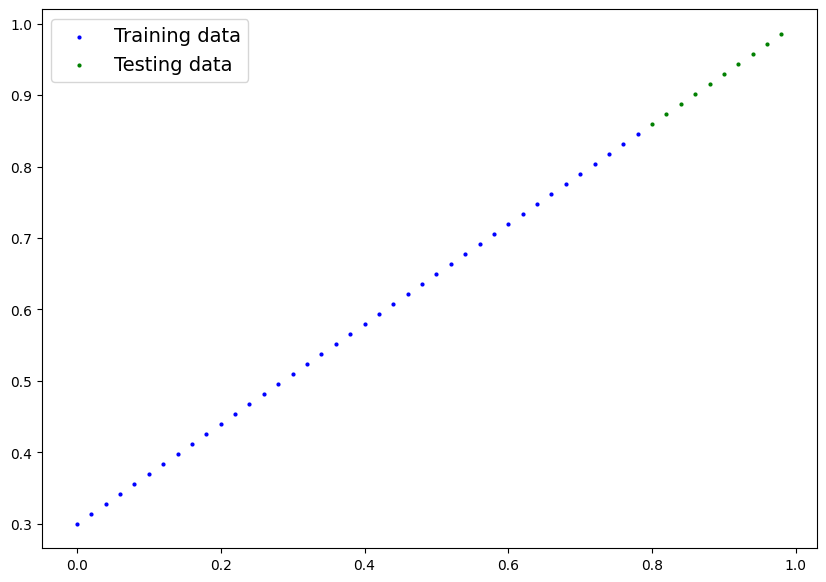

In [17]:
def plot_predictions(train_data=X_train,
                     train_labels=y_train,
                     test_data=X_test,
                     test_labels=y_test,
                     predictions=None):

    plt.figure(figsize=(10, 7))

    # Plot training data in blue
    plt.scatter(train_data, train_labels,
                c='b', s=4, label='Training data')

    # Plot test data in green
    plt.scatter(test_data, test_labels,
                c='g', s=4, label='Testing data')

    if predictions is not None:
        plt.scatter(test_data, predictions,
                    c='r', s=4, label='Predictions')

    plt.legend(prop={'size': 14})
plot_predictions()


In [19]:
# Subclass nn.Module to make our model
class LinearRegressionModelV2(nn.Module):
    def __init__(self):
        super().__init__()

        # Use nn.Linear() for creating the model parameters
        self.linear_layer = nn.Linear(
            in_features=1,
            out_features=1) # Linear => y = wx+b

    # Define the forward computation (input data x flows through nn.Linear())
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.linear_layer(x)


# Set the manual seed when creating the model
# (this isn't always needed but is used for demonstrative purposes,
# try commenting it out and seeing what happens)
torch.manual_seed(42)

model_1 = LinearRegressionModelV2()

model_1, model_1.state_dict()

(LinearRegressionModelV2(
   (linear_layer): Linear(in_features=1, out_features=1, bias=True)
 ),
 OrderedDict([('linear_layer.weight', tensor([[0.7645]])),
              ('linear_layer.bias', tensor([0.8300]))]))

Text(0.5, 1.0, 'predictions before training (red = random guesses)')

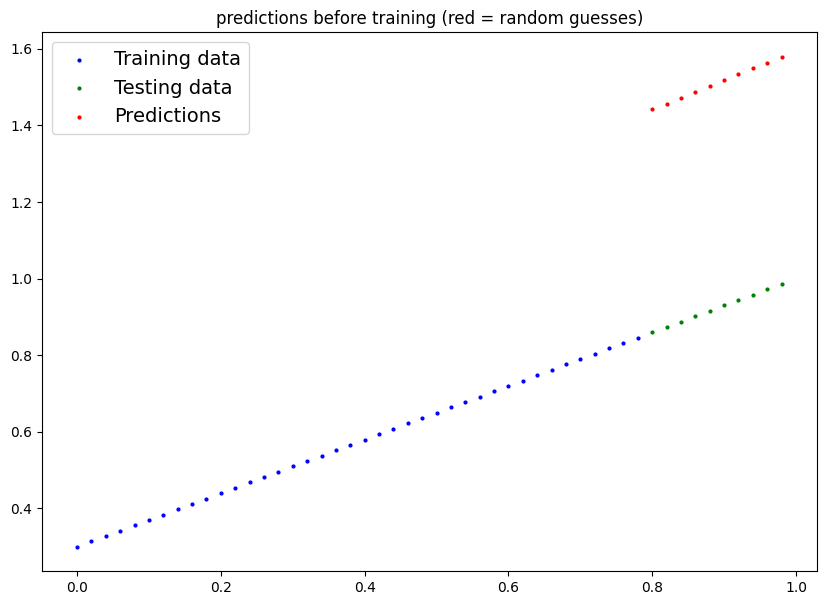

In [20]:
# See model's untrained predictions (on test set)
model_1.eval()
with torch.inference_mode():
  y_preds_early = model_1(X_test)

plot_predictions(predictions=y_preds_early)
plt.title("predictions before training (red = random guesses)")


In [23]:
# Create loss function
loss_fn = nn.L1Loss()

# Create optimizer
optimizer = torch.optim.SGD(
    params=model_1.parameters(),  # optimize newly created model's parameters
    lr=0.01) # weight and bias

In [22]:
# Trun model into evaluation mode
model_1.eval()

# Make predictions on test data
with torch.inference_mode():
  y_preds = model_1(X_test)
y_preds


tensor([[1.4416],
        [1.4569],
        [1.4722],
        [1.4875],
        [1.5028],
        [1.5181],
        [1.5334],
        [1.5487],
        [1.5640],
        [1.5793]])

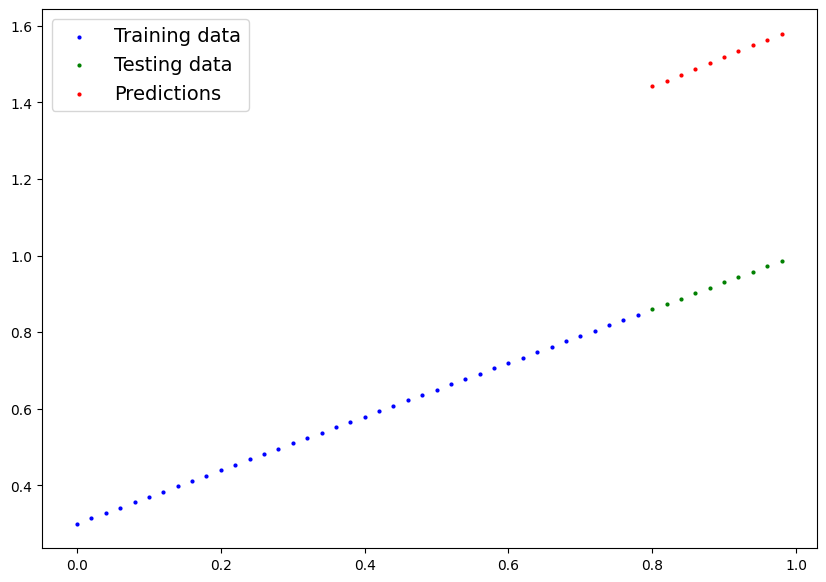

In [24]:
# Put data on the CPU and plot it
plot_predictions(predictions=y_preds)

In [ ]:
torch.save(model_1.state_dict(), 'trained_model.pth')